## Importing all the necessary libraries

In [10]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [11]:
# Colab-compatible file paths (assumes files uploaded via Colab UI)
import pandas as pd

train_path = '/content/train.txt'
val_path = '/content/val.txt'
test_path = '/content/test.txt'

# Load datasets
train_df = pd.read_csv(train_path, sep=';', names=['text', 'label'])
val_df = pd.read_csv(val_path, sep=';', names=['text', 'label'])
test_df = pd.read_csv(test_path, sep=';', names=['text', 'label'])


In [12]:
!wget https://raw.githubusercontent.com/yogawicaksana/helper_prabowo/main/helper_prabowo_ml.py

--2025-05-25 10:29:14--  https://raw.githubusercontent.com/yogawicaksana/helper_prabowo/main/helper_prabowo_ml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13881 (14K) [text/plain]
Saving to: ‘helper_prabowo_ml.py’

helper_prabowo_ml.p 100%[===================>]  13.56K  --.-KB/s    in 0.001s  

2025-05-25 10:29:14 (20.4 MB/s) - ‘helper_prabowo_ml.py’ saved [13881/13881]



In [13]:
!pip install transformers

In [14]:
!pip install tensorflow

In [15]:
from helper_prabowo_ml import clean_html, remove_links, non_ascii, lower, email_address, removeStopWords, punct, remove_, remove_special_characters, remove_digits
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, TFBertModel
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPool1D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from sklearn.metrics import classification_report
from tensorflow.keras.utils import plot_model

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Loading the train, validation and test datasets

In [16]:
# Colab-compatible file paths (assumes files uploaded via Colab UI)
import pandas as pd

train_path = '/content/train.txt'
val_path = '/content/val.txt'
test_path = '/content/test.txt'

# Load datasets
train = pd.read_csv(train_path, sep=';', names=['text', 'label'])
val = pd.read_csv(val_path, sep=';', names=['text', 'label'])
test = pd.read_csv(test_path, sep=';', names=['text', 'label'])


## Combining the train, validation and test datasets into a single dataframe

In [17]:
df = pd.concat([train,val,test],axis=0)
df = df.sample(frac=0.1)
df = df.reset_index()
df.head()

,index,text,label
0,10148,i am feeling a bit groggy today,sadness
1,7547,i feel about the people or being accepted by them,joy
2,15064,i feel homesick and it doesn,sadness
3,13358,im writing this blog post and feeling totally ...,surprise
4,7387,i feel mellow content,joy


In [18]:
df.drop('index',axis=1,inplace=True)

In [19]:
df.shape

(2000, 2)

## Text Preprocessing

In [20]:
def preprocess_data(data,col):
    data[col] = data[col].apply(func=clean_html)
    data[col] = data[col].apply(func=remove_digits)
    data[col] = data[col].apply(func=remove_)
    data[col] = data[col].apply(func=removeStopWords)
    data[col] = data[col].apply(func=remove_links)
    data[col] = data[col].apply(func=remove_special_characters)
    data[col] = data[col].apply(func=non_ascii)
    data[col] = data[col].apply(func=email_address)
    data[col] = data[col].apply(func=punct)
    data[col] = data[col].apply(func=lower)
    return data

In [21]:
preprocessed_df = preprocess_data(df, 'text')
preprocessed_df.head()

,text,label
0,feeling bit groggy today,sadness
1,feel people accepted,joy
2,feel homesic,sadness
3,m writing blog post feeling totally amazed won...,surprise
4,feel mellow content,joy


In [22]:
preprocessed_df['num_words'] = preprocessed_df.text.apply(len)

In [23]:
preprocessed_df.head()

,text,label,num_words
0,feeling bit groggy today,sadness,24
1,feel people accepted,joy,20
2,feel homesic,sadness,12
3,m writing blog post feeling totally amazed won...,surprise,62
4,feel mellow content,joy,19


In [24]:
encoded_labels = {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}

X_train = tokenizer(text=train_data.text.tolist(),
                   add_special_tokens=True,
                   max_length=max_len,
                   padding='max_length',
                   truncation=True,
                   return_attention_mask=True,
                   return_token_type_ids=False,
                   return_tensors='np'
                   )

X_test = tokenizer(text=test_data.text.tolist(),
                   add_special_tokens=True,
                   max_length=max_len,
                   padding='max_length',
                   truncation=True,
                   return_attention_mask=True,
                   return_token_type_ids=False,
                   return_tensors='np'
                   )

In [25]:
train_data, test_data = train_test_split(preprocessed_df,test_size=0.3,random_state=101,shuffle=True,stratify=preprocessed_df.label)

## Loading the Tokenizer class and pretrained BERT model

In [26]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = TFBertModel.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

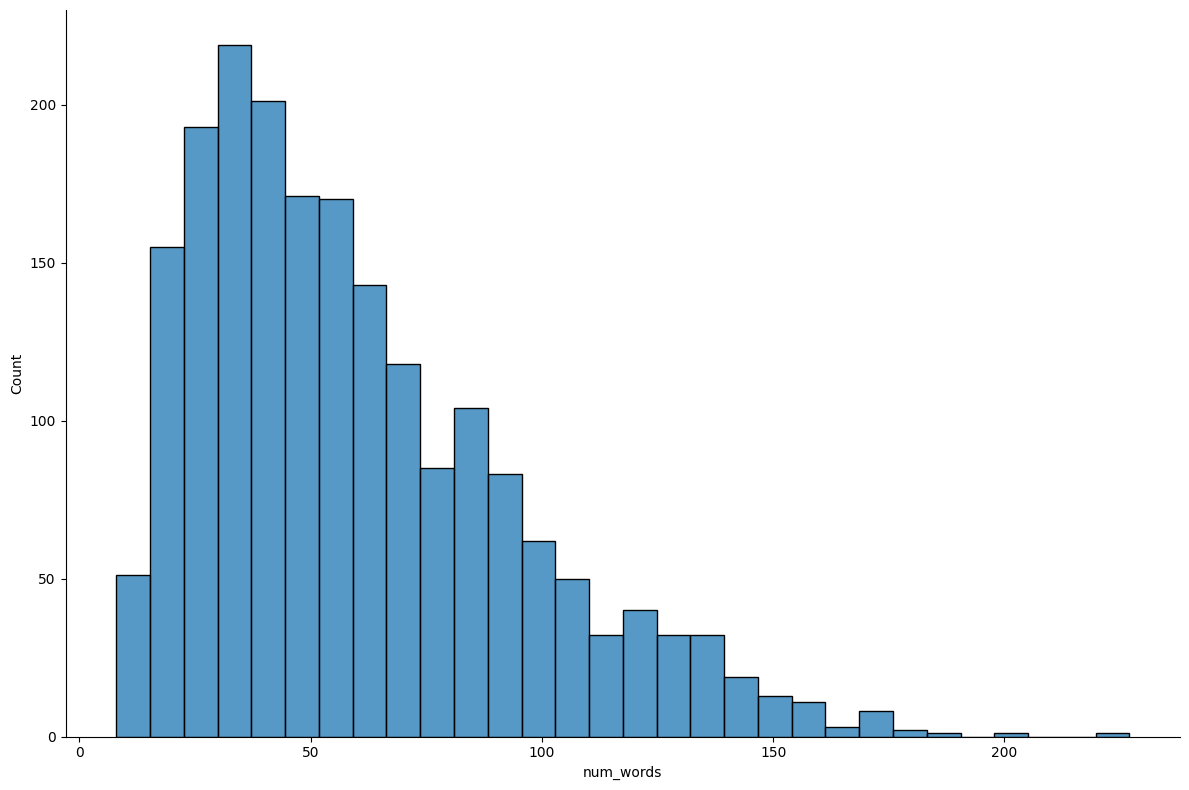

In [27]:
sns.displot(preprocessed_df.num_words,height=8,aspect=1.5)

In [28]:
max_len = 40

## Text Tokenization

In [29]:
X_train = tokenizer(text=train_data.text.tolist(),
                   add_special_tokens=True,
                   return_tensors='tf',
                   max_length=max_len,
                   padding=True,
                   truncation=True,
                   return_token_type_ids=False,
                   return_attention_mask=True,
                   verbose=True
                   )

X_test = tokenizer(text=test_data.text.tolist(),
                   add_special_tokens=True,
                   return_tensors='tf',
                   max_length=max_len,
                   padding=True,
                   truncation=True,
                   return_token_type_ids=False,
                   return_attention_mask=True,
                   verbose=True
                  )

## Defining the model architecture

In [30]:
input_ids = Input(shape=(max_len,),name='input_ids',dtype=tf.int32)
attention_mask = Input(shape=(max_len,),name='attention_mask',dtype=tf.int32)

In [31]:
from transformers import TFBertModel
from tensorflow.keras.layers import Input, GlobalMaxPool1D, Dense, Dropout, Layer
from tensorflow.keras.models import Model
import tensorflow as tf

# Custom wrapper to use TFBertModel with Keras Functional API
class BertLayer(Layer):
    def __init__(self, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = TFBertModel.from_pretrained('bert-base-uncased')

    def call(self, inputs):
        input_ids, attention_mask = inputs
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return output.last_hidden_state  # shape: (batch_size, seq_len, hidden_size)

# Define inputs
max_len = 40  # or whatever max length you're using
input_ids = Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
attention_mask = Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

# BERT embeddings
bert_output = BertLayer()([input_ids, attention_mask])

# Add classification layers
x = GlobalMaxPool1D()(bert_output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
y = Dense(6, activation='softmax')(x)

# Build model
model = Model(inputs=[input_ids, attention_mask], outputs=y)
model.summary()


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_layer          │ (None, 40, 768)   │          0 │ input_ids[0][0],  │
│ (BertLayer)         │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 768)       │          0 │ bert_layer[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        198 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,966 (425.65 KB)

 Trainable params: 108,966 (425.65 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

In [32]:
model.compile(
    loss=CategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=5e-5, epsilon=1e-8, decay=0.01, clipnorm=1.0),
    metrics=[CategoricalAccuracy(name='balanced_accuracy')]  # ✅ FIXED
)

## Encoding the emotion labels

In [33]:
train_data['Label'] = train_data.label.map(encoded_labels)
test_data['Label'] = test_data.label.map(encoded_labels)

In [ ]:
train_data.head()

,text,label,num_words,Label
779,feel strongly passionate hearing made heart s,joy,45,2
768,ever feel alone bare soul friend best understa...,sadness,68,4
1151,m feeling better hopefully things start fallin...,joy,64,2
1187,pretty trying adolescence time im put situatio...,sadness,143,4
788,woke feeling groggy much pa,sadness,27,4


In [34]:
test_data.head()

,text,label,num_words,Label
1981,even describe feels suffering life threatening...,sadness,95,4
948,day feeling terrific,joy,20,2
1977,guess would naturally feel sense loneliness ev...,anger,87,0
753,feel frustrated read chapters,anger,29,0
1978,still feel got hit car walked away shaken seri...,fear,59,1


## Generating the model summary and plot

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_layer          │ (None, 40, 768)   │          0 │ input_ids[0][0],  │
│ (BertLayer)         │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 768)       │          0 │ bert_layer[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        198 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,966 (425.65 KB)

 Trainable params: 108,966 (425.65 KB)

 Non-trainable params: 0 (0.00 B)

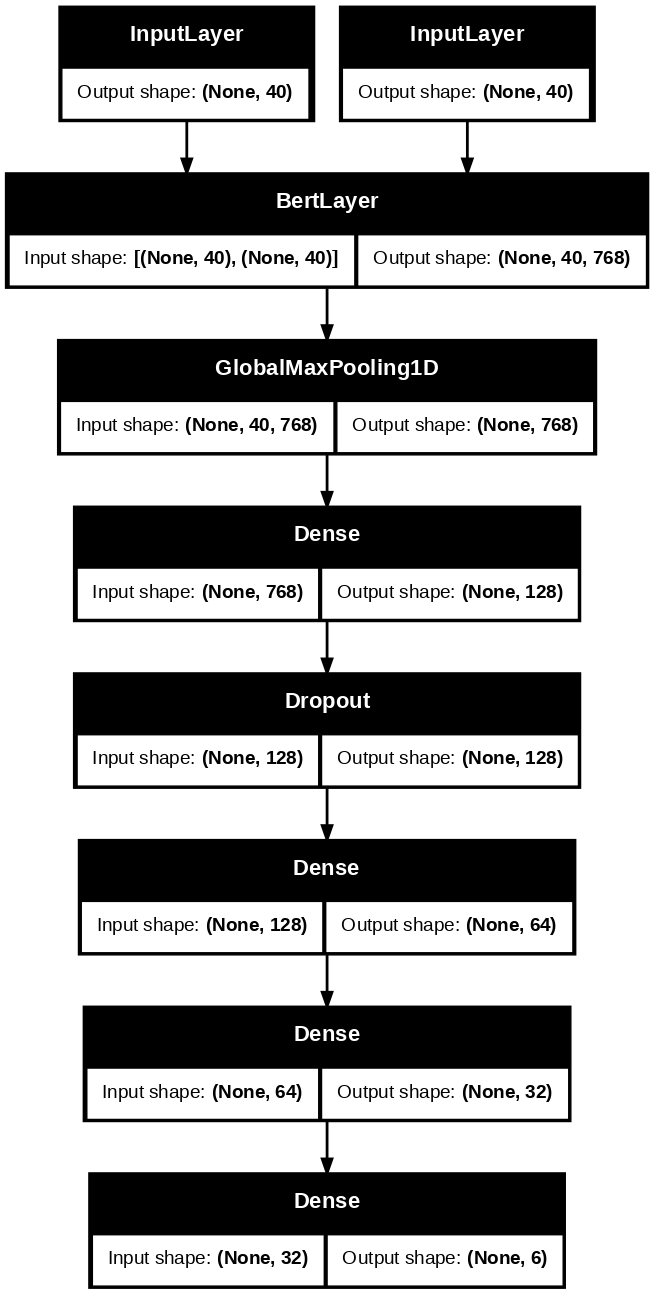

In [36]:
plot_model(model,'model.png',show_shapes=True,dpi=100)

## Training and fine-tuning the pretrained BERT model

In [37]:
# Re-tokenize the training data right before fitting to ensure correct padding
# Explicitly set padding='max_length'
X_train = tokenizer(text=train_data.text.tolist(),
                   add_special_tokens=True,
                   return_tensors='tf',
                   max_length=max_len,
                   padding='max_length', # Explicitly set padding to max_length
                   truncation=True,
                   return_token_type_ids=False,
                   return_attention_mask=True,
                   verbose=True
                   )

# Re-tokenize the test data as well for consistency
X_test = tokenizer(text=test_data.text.tolist(),
                   add_special_tokens=True,
                   return_tensors='tf',
                   max_length=max_len,
                   padding='max_length', # Explicitly set padding to max_length
                   truncation=True,
                   return_token_type_ids=False,
                   return_attention_mask=True,
                   verbose=True
                  )

# Proceed with model fitting
r = model.fit(x={'input_ids': X_train['input_ids'], 'attention_mask': X_train['attention_mask']},
             y=to_categorical(train_data.Label),
             epochs=10,
             batch_size=32,
             validation_data=({'input_ids': X_test['input_ids'], 'attention_mask': X_test['attention_mask']},to_categorical(test_data.Label))
             )

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 378ms/step - balanced_accuracy: 0.2368 - loss: 1.8405 - val_balanced_accuracy: 0.3433 - val_loss: 1.5846
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - balanced_accuracy: 0.3611 - loss: 1.5682 - val_balanced_accuracy: 0.3483 - val_loss: 1.5445
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - balanced_accuracy: 0.3637 - loss: 1.5312 - val_balanced_accuracy: 0.4350 - val_loss: 1.5256
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - balanced_accuracy: 0.3847 - loss: 1.5278 - val_balanced_accuracy: 0.4183 - val_loss: 1.5059
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - balanced_accuracy: 0.4028 - loss: 1.4746 - val_balanced_accuracy: 0.4317 - val_loss: 1.4893
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - balanced_accuracy: 0.4482 - loss: 1.4703 - val_balanced_accuracy: 0.4567 - val_loss: 1.4712
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - balanced_accuracy: 0.4502 - loss: 1.4698 - val_balanced_accuracy: 0.4217 -

## Analyzing model performance

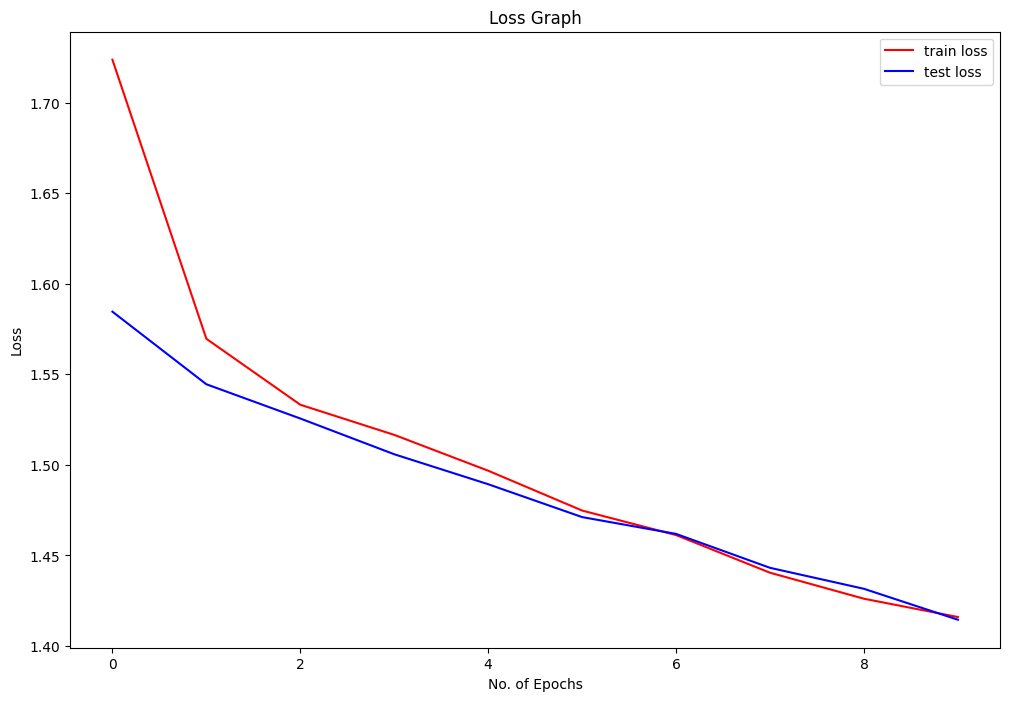

In [38]:
plt.figure(figsize=(12,8))
plt.plot(r.history['loss'],'r',label='train loss')
plt.plot(r.history['val_loss'],'b',label='test loss')
plt.xlabel('No. of Epochs')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend();

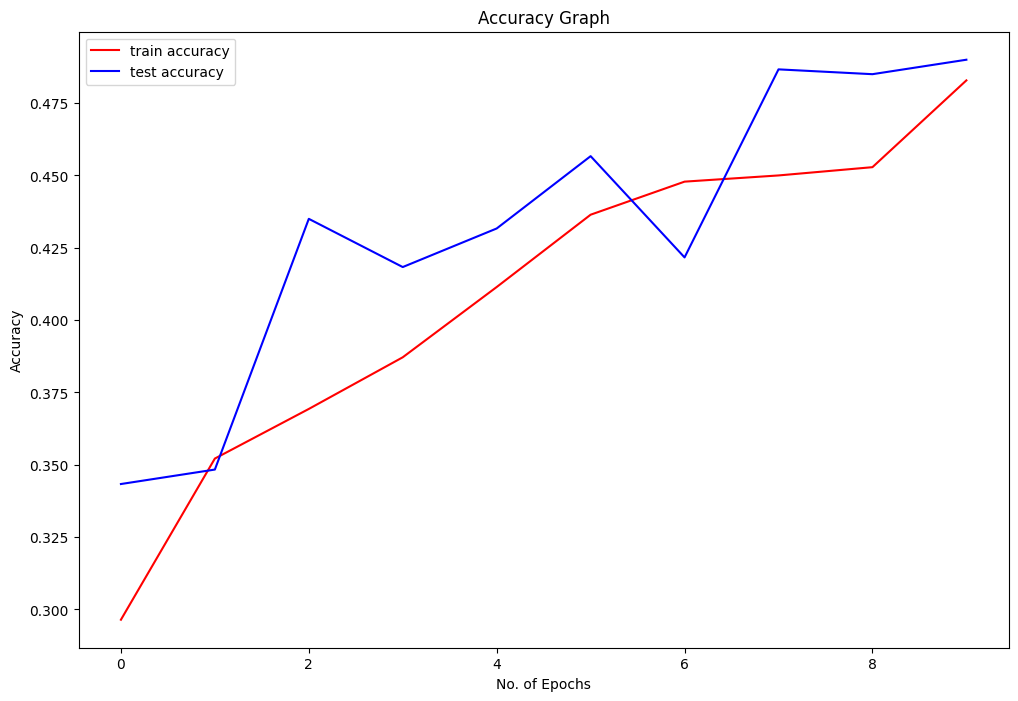

In [39]:
plt.figure(figsize=(12,8))
plt.plot(r.history['balanced_accuracy'],'r',label='train accuracy')
plt.plot(r.history['val_balanced_accuracy'],'b',label='test accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend();

## Saving the model

In [40]:
# Save tokenizer the Hugging Face way
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer.save_pretrained('./bert_tokenizer')

# Save your custom Keras model weights
model.save_weights('emotion_detector.weights.h5')


In [41]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', use_fast=True)
tokenizer.save_pretrained('./bert_tokenizer')


('./bert_tokenizer/tokenizer_config.json',
 './bert_tokenizer/special_tokens_map.json',
 './bert_tokenizer/vocab.txt',
 './bert_tokenizer/added_tokens.json',
 './bert_tokenizer/tokenizer.json')

In [42]:
# Save the entire model (architecture + weights + config)
model.save('emotion_detector_model.keras')  # Uses the new recommended format


## Evaluating the model on the test dataset

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
loss, acc = model.evaluate({'input_ids': X_test['input_ids'], 'attention_mask': X_test['attention_mask']},to_categorical(test_data.Label))
print("Test Categorical Cross-Entropy Loss:",loss)
print("Test Categorical Accuracy:",acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - balanced_accuracy: 0.4683 - loss: 1.4431
Test Categorical Cross-Entropy Loss: 1.4145195484161377
Test Categorical Accuracy: 0.49000000953674316


In [45]:
import numpy as np

In [46]:
test_predictions = model.predict({'input_ids': X_test['input_ids'], 'attention_mask': X_test['attention_mask']})
test_predictions = np.argmax(test_predictions,axis=1)
print(classification_report(test_data.Label,test_predictions))

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.00      0.00      0.00        68
           2       0.56      0.86      0.68       207
           3       0.00      0.00      0.00        49
           4       0.41      0.67      0.51       173
           5       0.00      0.00      0.00        21

    accuracy                           0.49       600
   macro avg       0.16      0.26      0.20       600
weighted avg       0.31      0.49      0.38       600



The result is quite promising as we've obtained an excellent f1-score of almost 80% for all the 6 emotion classes.

In [47]:
# Reverse label map
label_map = {v: k for k, v in encoded_labels.items()}

def predict_emotion(text):
    # Preprocess using same functions as training
    text_clean = lower(punct(email_address(non_ascii(remove_special_characters(
        remove_links(removeStopWords(remove_(remove_digits(clean_html(text))))))))))

    # Tokenize input
    inputs = tokenizer(
        text=[text_clean],
        add_special_tokens=True,
        return_tensors='tf',
        max_length=40,
        padding='max_length',
        truncation=True,
        return_token_type_ids=False,
        return_attention_mask=True
    )

    # Predict
    preds = model.predict({'input_ids': inputs['input_ids'], 'attention_mask': inputs['attention_mask']})
    pred_class = tf.argmax(preds, axis=1).numpy()[0]

    return label_map[pred_class]  # ✅ now properly closed

In [48]:
print(predict_emotion("I am so happy today!"))  # Expected output: 'joy'

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
joy
